In [460]:
import math

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [461]:
def f(x):
    return 3*x**2 - 4*x + 5

In [462]:
f(3.0)

20.0

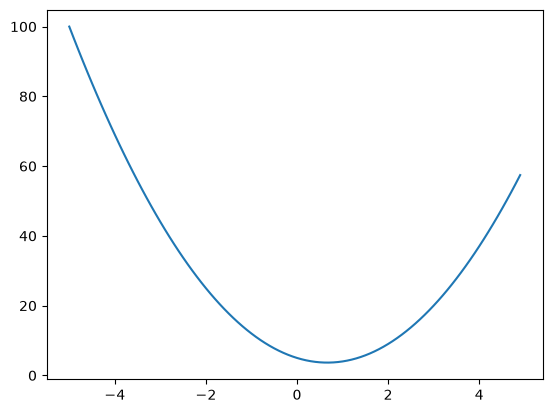

In [463]:
xs = np.arange(-5, 5, 0.1)
ys = f(xs)
plt.plot(xs, ys)

In [464]:
h = 0.0000001
x = 2/3
(f(x + h) - f(x)) / h

2.9753977059954195e-07

In [465]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [466]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c
print((d2 - d1) / h)

0.9999999999976694


In [467]:
class Value:
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
            other = other if isinstance(other, Value) else Value(other)
            def _backward():
                self.grad += 1.0 * out.grad
                other.grad += 1.0 * out.grad
            out = Value(self.data + other.data, (self, other), '+')
            out._backward = _backward
            return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out = Value(self.data * other.data, (self, other), '*')
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out = Value(self.data**other, (self,), f'**{other}')
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out = Value(t, (self,), 'tanh')
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [468]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
a/b

Value(data=-0.6666666666666666)

In [469]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2.0, label="f")
L = d * f
L.label = "L"


In [470]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [471]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [472]:
o.grad = 1.0
n.grad = 0.5

In [473]:
o.grad = 1.0
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
for node in reversed(topo):
    node._backward()

In [474]:
1+a

Value(data=3.0)

In [475]:
x1.grad

-2.9999999999999996

In [476]:
a = Value(2.0, label='a')
b = a + a; b.label = 'b'
b.backward()

a.grad

2.0

In [477]:
import torch

x1 = torch.tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.tensor([1.0]).double(); w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("x1.grad:", x1.grad.item())
print("x2.grad:", x2.grad.item())
print("w1.grad:", w1.grad.item())
print("w2.grad:", w2.grad.item())
print("b.grad:", b.grad.item())

0.7071066904050358
x1.grad: -1.5000003851533106
x2.grad: 0.5000001283844369
w1.grad: 1.0000002567688737
w2.grad: 0.0
b.grad: 0.5000001283844369


In [478]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [479]:
import random


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [480]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.8702419904660568)

In [481]:
len(n.parameters())

41

In [482]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

ypred = [n(x) for x in xs]

In [483]:
for k in range(200):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for yout, ygt in zip(ypred, ys))

    for p in n.parameters():
        # reset the gradient to zero before backward pass
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update parameters
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(k, loss.data)

0 6.388121999024987
1 3.11266993633057
2 3.4103743144465333
3 4.119880373732391
4 3.9315356292219437
5 2.2227389170485696
6 0.6860662108330222
7 0.2190862338148912
8 0.1418584871233257
9 0.1109332586086219
10 0.09112810699971889
11 0.07705423238571613
12 0.06652111507042574
13 0.05835690237459297
14 0.05185823195846891
15 0.04657397277231012
16 0.04220101573030959
17 0.03852826033983876
18 0.0354043232471994
19 0.032717947790759906
20 0.03038563133956075
21 0.02834354745937339
22 0.02654212127555925
23 0.024942296548285357
24 0.02351291123559012
25 0.022228816961468747
26 0.021069508411392494
27 0.02001810896021278
28 0.019060609450511516
29 0.01818528967657758
30 0.017382273607187845
31 0.01664318377787273
32 0.015960870098304804
33 0.015329195115429538
34 0.014742862544460346
35 0.014197279274699656
36 0.013688443502084858
37 0.013212853421205435
38 0.012767432220436643
39 0.012349466098358708
40 0.011956552750820136
41 0.011586558331399219
42 0.011237581310284364
43 0.01090792198129

In [484]:
ypred

[Value(data=0.9768443811984712),
 Value(data=-0.9865063352775368),
 Value(data=-0.9733405722337984),
 Value(data=0.9811304907825289)]